## Introduction

- This Project analyzes hospital encounter data using SQL to identify key performance metricsand patient risk factors associated with 30-day readmissions.
- The goal is to simulate real-world healthcare analytics workflow., including database querying cohort segmentation, and KPI reporting. 

## Data Model 
The dataset was structured into a relational format to simulate a real healthcare database

- Patient_table -> patient demographics
- encounters -> hospital visit details
- utilities -> medication and visit utilization

These tables are linked via 
- patient_nbr
- encounter-id

In [26]:
import pandas as pd
import sqlite3

#load data
df = pd.read_csv('../data/diabetic_data.csv')

#connect to database
conn = sqlite3.connect('../hospital.db')

#creatate a table
df.to_sql('patients', conn, if_exists='replace', index=False)

#confirm 
pd.read_sql("SELECT * FROM patients LIMIT 5;", conn)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [22]:
#total patients 
import pandas as pd

pd.read_sql("""
SELECT COUNT(*) as total_patients
FROM patients;
""", conn)

,total_patients
0,101766


In [24]:
#Readmission Breakdown

pd.read_sql("""
SELECT readmitted, COUNT(*) as count
FROM patients
GROUP BY readmitted;
""", conn)

,readmitted,count
0,<30,11357
1,>30,35545
2,NO,54864


In [27]:
#Average Length of Stay

pd.read_sql("""
SELECT AVG(time_in_hospital) as avg_los
FROM patients;
""", conn)

,avg_los
0,4.395987


In [28]:
#ReadmissionRate by Age

pd.read_sql("""
SELECT age, 
        AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM patients
GROUP BY age
ORDER BY readmission_rate DESC;
""", conn)

,age,readmission_rate
0,[20-30),0.142426
1,[80-90),0.120835
2,[70-80),0.117731
3,[30-40),0.112318
4,[60-70),0.111284
5,[90-100),0.110992
6,[40-50),0.106040
7,[50-60),0.096662
8,[10-20),0.057887
9,[0-10),0.018634


In [6]:
#Do longer hospital stays increase readmission risk?

pd.read_sql("""
SELECT time_in_hospital,
        AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as patient_count
FROM patients
GROUP BY time_in_hospital
ORDER BY time_in_hospital;
""", conn)

,time_in_hospital,readmission_rate,patient_count
0,1,0.081785,14208
1,2,0.099396,17224
2,3,0.106668,17756
3,4,0.118070,13924
4,5,0.120309,9966
5,6,0.125879,7539
6,7,0.128350,5859
7,8,0.142337,4391
8,9,0.137242,3002
9,10,0.143467,2342


## SQL Analysis 

### Patient Volume
### Readmission Metrics
### Length of Stay Analysis

## Cohort Analysis 

### High Utilizers 
### Long Stay Patients
### Medication Burden 

## KPI Dashboard

### Summery Metrics
### Trend Analysis 

In [29]:
import pandas as pd
import sqlite3

df = pd.read_csv('../data/diabetic_data.csv')
conn = sqlite3.connect('../hospital.db')

In [30]:
patients = df[['patient_nbr', 'age', 'gender']].drop_duplicates()
patients.to_sql('patient_table', conn, if_exists='replace', index=False)

73094

In [9]:
encounters = df[['encounter_id', 'patient_nbr', 'time_in_hospital', 'readmitted']]
encounters.to_sql('encounters', conn, if_exists='replace', index=False)

101766

In [10]:
utilization = df[['encounter_id', 'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency']]
utilization.to_sql('utilization', conn, if_exists='replace', index=False)

In [14]:
pd.read_sql("""
SELECT p.age,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as patient_count
FROM encounters e
JOIN patient_table p
    ON e.patient_nbr = p.patient_nbr
GROUP BY p.age
ORDER BY readmission_rate DESC;
""", conn)

,age,readmission_rate,patient_count
0,[20-30),0.146636,1739
1,[80-90),0.121656,18092
2,[70-80),0.119705,27359
3,[30-40),0.113780,3955
4,[60-70),0.112532,23620
5,[90-100),0.111037,3017
6,[40-50),0.109093,10184
7,[50-60),0.099453,18089
8,[10-20),0.081267,726
9,[0-10),0.018405,163


In [16]:
pd.read_sql("""
SELECT e.time_in_hospital,
        AVG(u.num_medications) as avg_meds,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM encounters e
JOIN utilization u
    on e.encounter_id = u.encounter_id
GROUP BY e.time_in_hospital
ORDER BY e.time_in_hospital;
""", conn)

,time_in_hospital,avg_meds,readmission_rate
0,1,11.094243,0.081785
1,2,12.522062,0.099396
2,3,14.358414,0.106668
3,4,15.967107,0.118070
4,5,17.451836,0.120309
5,6,18.622231,0.125879
6,7,19.978495,0.128350
7,8,21.118880,0.142337
8,9,21.980680,0.137242
9,10,23.247225,0.143467


In [20]:
pd.read_sql("""
SELECT p.age,
        AVG(u.num_medications) as avg_meds,
        AVG(e.time_in_hospital) as avg_los,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
        COUNT(*) as count
FROM encounters e 
JOIN patient_table p ON e.patient_nbr = p.patient_nbr
JOIN utilization u ON e.encounter_id = u.encounter_id
GROUP BY p.age
ORDER BY readmission_rate DESC
LIMIT 10;
""", conn)


,age,avg_meds,avg_los,readmission_rate,count
0,[20-30),12.089707,3.579643,0.146636,1739
1,[80-90),15.334623,4.786591,0.121656,18092
2,[70-80),16.432253,4.588435,0.119705,27359
3,[30-40),14.161820,3.806574,0.113780,3955
4,[60-70),17.191490,4.393776,0.112532,23620
5,[90-100),13.852171,4.753397,0.111037,3017
6,[40-50),15.501080,4.057345,0.109093,10184
7,[50-60),16.640666,4.139256,0.099453,18089
8,[10-20),8.356749,3.213499,0.081267,726
9,[0-10),6.165644,2.546012,0.018405,163


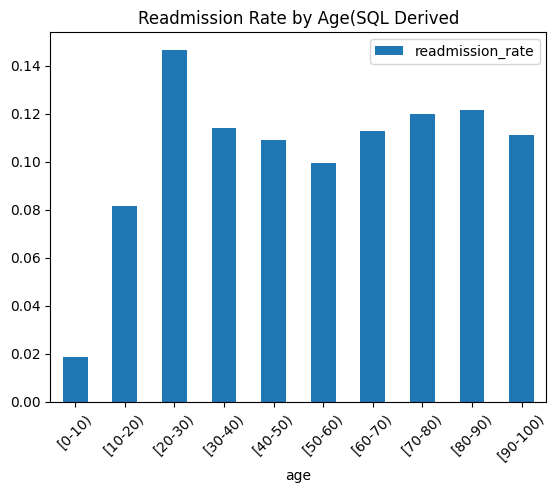

In [22]:
import matplotlib.pyplot as plt

df_sql = pd.read_sql("""
SELECT p.age,
        AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate
FROM encounters e
JOIN patient_table p 
ON e.patient_nbr = p.patient_nbr
GROUP BY p.age
""", conn)

df_sql.plot(x='age', y='readmission_rate', kind='bar')
plt.title ("Readmission Rate by Age(SQL Derived")
plt.xticks(rotation=45)
plt.show()

## SQL-Based Analysis

### Muli_Table Querrying
### Readmission Risk by Demographics
### Clinical Complexity annd Outcomes

In [24]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../hospital.db')

In [25]:
#High Utilization 

pd.read_sql ("""
SELECT e.encounter_id,
        CASE
            WHEN (u.number_outpatient + u.number_inpatient) >= 3 THEN 1
            ELSE 0
        END AS high_utilizer,
        e.readmitted
FROM encounters e
JOIN utilization u
ON e.encounter_id = u.encounter_id
LIMIT 10;
""", conn)

,encounter_id,high_utilizer,readmitted
0,2278392,0,NO
1,149190,0,>30
2,64410,1,NO
3,500364,0,NO
4,16680,0,NO
5,35754,0,>30
6,55842,0,NO
7,63768,0,>30
8,12522,0,NO
9,15738,0,NO


In [28]:
#High Medicaftion Burden 

pd.read_sql("""
SELECT encounter_id,
        CASE
            WHEN time_in_hospital >= 7 THEN 1
            ELSE 0
        END AS long_stay,
        readmitted
FROM encounters;
""", conn)

,encounter_id,long_stay,readmitted
0,2278392,0,NO
1,149190,0,>30
2,64410,0,NO
3,500364,0,NO
4,16680,0,NO
...,...,...,...
101761,443847548,0,>30
101762,443847782,0,NO
101763,443854148,0,NO
101764,443857166,1,NO


In [30]:
#High Medication Burden 

pd.read_sql("""
SELECT encounter_id,
        CASE
            WHEN num_medications >=15 THEN 1
            ELSE 0
        END AS high_med_burden
FROM utilization;
""", conn)

,encounter_id,high_med_burden
0,2278392,0
1,149190,1
2,64410,0
3,500364,1
4,16680,0
...,...,...
101761,443847548,1
101762,443847782,1
101763,443854148,0
101764,443857166,1


In [35]:
#Combined cohorts 

pd.read_sql("""
SELECT e.encounter_id,
        p.age,
        e.time_in_hospital,
        u.num_medications,

        CASE
            WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0
        END AS high_utilizer,

        CASE
            WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0
        END AS long_stay,

        CASE
            WHEN u.num_medications >= 15 THEN 1 ELSE 0
        END AS high_med_burden,

        CASE
            WHEN e.readmitted = '<30' THEN 1 ELSE 0
        END AS readmitted_flag

FROM encounters e
JOIN patient_table p ON e.patient_nbr = p.patient_nbr
JOIN utilization u ON e.encounter_id = u.encounter_id;
""", conn)
            

,encounter_id,age,time_in_hospital,num_medications,high_utilizer,long_stay,high_med_burden,readmitted_flag
0,2278392,[0-10),1,1,0,0,0,0
1,149190,[10-20),3,18,0,0,1,0
2,64410,[20-30),2,13,1,0,0,0
3,500364,[30-40),2,16,0,0,1,0
4,16680,[40-50),1,8,0,0,0,0
...,...,...,...,...,...,...,...,...
106939,443847548,[70-80),3,16,0,0,1,0
106940,443847782,[80-90),5,18,0,0,1,0
106941,443854148,[70-80),1,9,0,0,0,0
106942,443857166,[80-90),10,21,0,1,1,0


In [41]:
#Readmission Rate

pd.read_sql("""
SELECT
    high_utilizer,
    AVG(readmitted_flag) as readmission_rate,
    COUNT(*) as count
FROM (
    SELECT e.encounter_id,
            CASE 
                WHEN (u.number_outpatient + u.number_inpatient) >= 3 THEN 1 
                ELSE 0 
            END as high_utilizer,
            CASE 
                WHEN e.readmitted = '<30' THEN 1 
                ELSE 0 
            END as readmitted_flag
    FROM encounters e
    JOIN utilization u 
        ON e.encounter_id = u.encounter_id
)
GROUP BY high_utilizer;
""", conn)

,high_utilizer,readmission_rate,count
0,0,0.099121,88528
1,1,0.195045,13238


In [64]:
#long stay 

pd.read_sql("""
SELECT
    CASE 
        WHEN time_in_hospital >=7 THEN 1 
        ELSE 0 
    END as long_stay,
    AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count
fROM encounters
GROUP BY long_stay;
""", conn)
    
    

,long_stay,readmission_rate,count
0,0,0.106181,80617
1,1,0.132252,21149


In [65]:
#Medical Burden

pd.read_sql("""
SELECT
    CASE WHEN num_medications >=15 THEN 1 ELSE 0 END as high_med_burden,
    AVG(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count
FROM utilization u
JOIN encounters e ON u.encounter_id = e.encounter_id
GROUP BY high_med_burden;
""", conn)

,high_med_burden,readmission_rate,count
0,0,0.098578,49453
1,1,0.123908,52313


In [66]:
#Combination of above 

pd.read_sql("""
SELECT
    (CASE WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0 END +
     CASE WHEN e.time_in_hospital >=7 THEN 1 ELSE 0 END +
     CASE WHEN u.num_medications >=15 THEN 1 ELSE 0 END) AS risk_score,
    AVG(CASE WHEN e.readmitted ='<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count

FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id

GROUP BY risk_score
ORDER BY risk_score;
""", conn)
    

,risk_score,readmission_rate,count
0,0,0.086489,40271
1,1,0.113510,38860
2,2,0.146474,20065
3,3,0.203891,2570


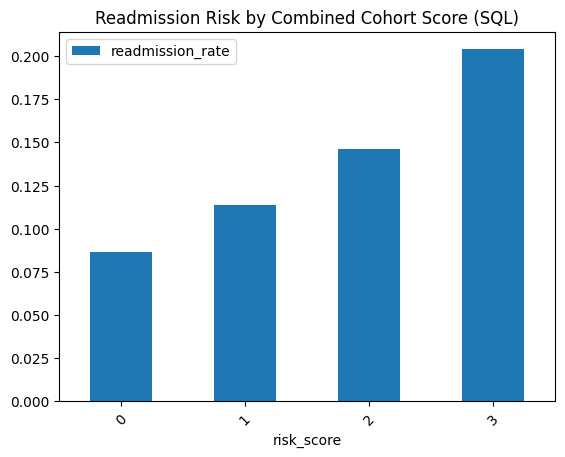

In [68]:
#Visual from above 

df_cohort = pd.read_sql("""
SELECT
    (CASE WHEN (u.number_outpatient + u.number_inpatient) >=3 THEN 1 ELSE 0 END +
     CASE WHEN e.time_in_hospital >=7 THEN 1 ELSE 0 END +
     CASE WHEN u.num_medications >=15 THEN 1 ELSE 0 END) AS risk_score,
    AVG(CASE WHEN e.readmitted ='<30' THEN 1 ELSE 0 END) as readmission_rate,
    COUNT (*) as count

From encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id

GROUP BY risk_score
ORDER BY risk_score;
""", conn)

import matplotlib.pyplot as plt

df_cohort.plot (x='risk_score', y='readmission_rate', kind='bar')
plt.title("Readmission Risk by Combined Cohort Score (SQL)")
plt.xticks(rotation=45)

plt.show()

## Cohort-Based Insights

- High utilizers demonstrateed significantly higher readmission rates, indicating recurrent healthcare interactions as a key signal.

- Patients with prolonged hospital stays also showed elevated risk, suggesting increase in clinical severity.

- A combined cohort-base risk score showed a strong stepwise increase in readmission probability, reinforcing the value of multi-factor risk stratification 

In [36]:
# KPI Dashboard
import pandas as pd
import sqlite3

conn = sqlite3.connect('../hospital.db')

#Single KPI Table 

kpi_summary = pd.read_sql("""
SELECT
    COUNT(*) as total_encounters,

    AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) as readmission_rate,

    AVG(e.time_in_hospital) as avg_los,

    AVG(u.num_medications) as avg_medications,

    AVG(
        CASE
            WHEN (
                (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
                 CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
                 CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
            ) THEN 1 ELSE 0
        END
    ) as high_risk_pct

FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id;
""", conn)

# Display with readable labels and formatted values
kpi_display = pd.DataFrame({
    'KPI': ['Total Encounters', 'Readmission Rate', 'Avg Length of Stay (days)', 'Avg Medications', 'High Risk Patient %'],
    'Value': [
        f"{int(kpi_summary['total_encounters'][0]):,}",
        f"{kpi_summary['readmission_rate'][0]:.1%}",
        f"{kpi_summary['avg_los'][0]:.1f}",
        f"{kpi_summary['avg_medications'][0]:.1f}",
        f"{kpi_summary['high_risk_pct'][0]:.1%}"
    ]
})
kpi_display

,KPI,Value
0,Total Encounters,"101,766"
1,Readmission Rate,11.2%
2,Avg Length of Stay (days),4.4
3,Avg Medications,16.0
4,High Risk Patient %,23.4%


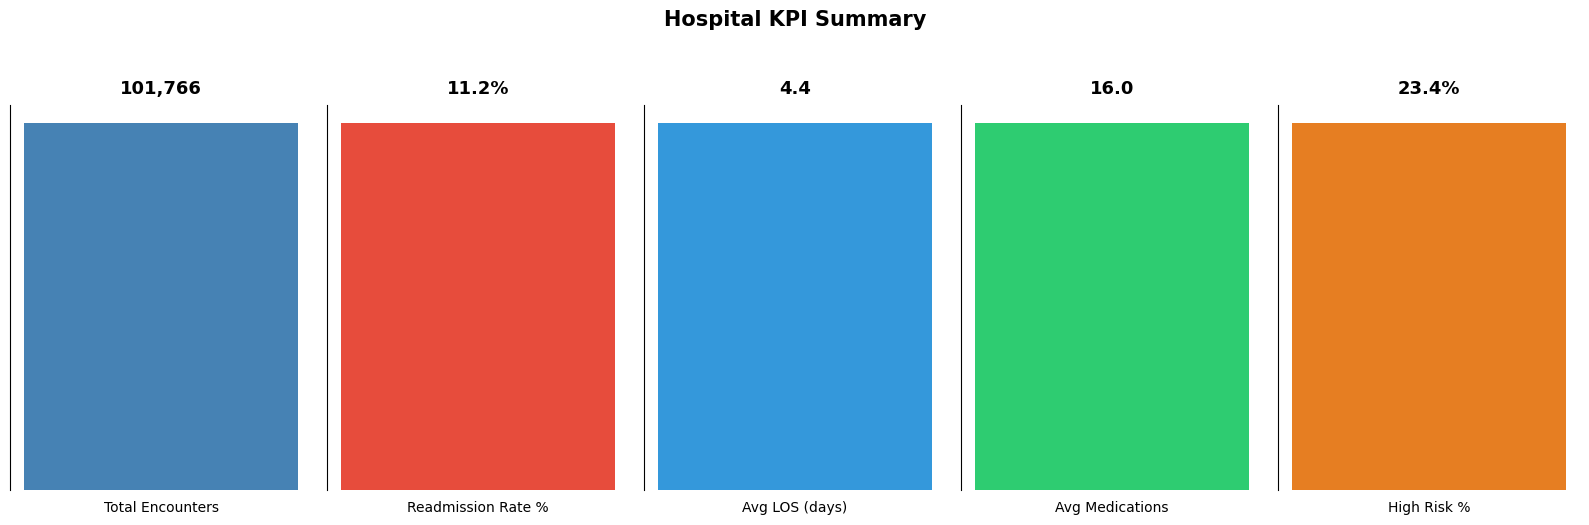

In [37]:
# Hospital KPI Summary - one subplot per metric
import matplotlib.pyplot as plt

kpis = [
    ("Total Encounters",   int(kpi_summary["total_encounters"][0]),      "{:,}",    "steelblue"),
    ("Readmission Rate %", kpi_summary["readmission_rate"][0] * 100,    "{:.1f}%", "#e74c3c"),
    ("Avg LOS (days)",     kpi_summary["avg_los"][0],                   "{:.1f}",  "#3498db"),
    ("Avg Medications",    kpi_summary["avg_medications"][0],            "{:.1f}",  "#2ecc71"),
    ("High Risk %",        kpi_summary["high_risk_pct"][0] * 100,       "{:.1f}%", "#e67e22"),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, (label, value, fmt, color) in zip(axes, kpis):
    ax.bar([" "], [value], color=color, width=0.5)
    ax.set_title(fmt.format(value), fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(label, fontsize=10, labelpad=8)
    ax.set_xticks([])
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

plt.suptitle("Hospital KPI Summary", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

## KPI Summary

- Overall readmission rate remains a key performance concern.

- High_risk patients, defined by combined utilization, los, and medication burden, represent a significant subset of the population.

- Length of stay demonstrates a relationship with readmission risk, suggesting potential intervention points durning hospitalization. 

## Deep Dive: LOS, Medication Burden & Readmission Risk

Examining how increased length of stay, high medication use (>10), and combined high-risk flags interact to drive 30-day readmissions.

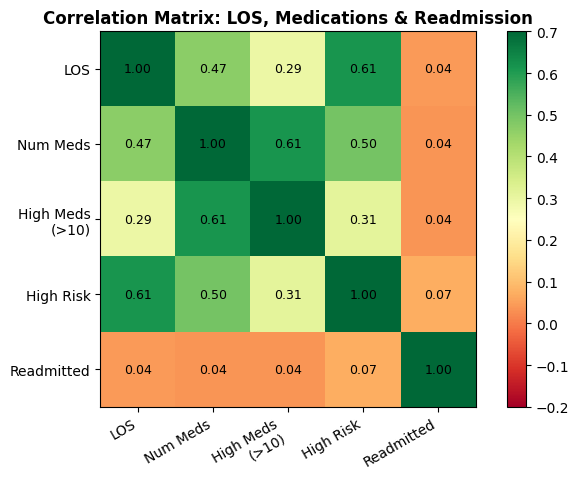

In [38]:
import numpy as np

# Patient-level features for correlation analysis
df_corr = pd.read_sql("""
SELECT
    e.time_in_hospital,
    u.num_medications,
    CASE WHEN u.num_medications > 10 THEN 1 ELSE 0 END as high_meds,
    CASE WHEN (
        (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
         CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
         CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
    ) THEN 1 ELSE 0 END as high_risk,
    CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END as readmitted
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
""", conn)

corr = df_corr.corr().round(3)

labels = ["LOS", "Num Meds", "High Meds\n(>10)", "High Risk", "Readmitted"]
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-0.2, vmax=0.7)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlation Matrix: LOS, Medications & Readmission", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [39]:
# Readmission rate by LOS category x medication burden x risk group
df_groups = pd.read_sql("""
SELECT
    CASE WHEN e.time_in_hospital <= 3 THEN 'Short (<=3d)'
         WHEN e.time_in_hospital <= 7 THEN 'Medium (4-7d)'
         ELSE 'Long (>7d)' END as los_category,
    CASE WHEN u.num_medications > 10 THEN 'High Meds (>10)' ELSE 'Low Meds (<=10)' END as med_group,
    CASE WHEN (
        (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
         CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
         CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
    ) THEN 'High Risk' ELSE 'Standard Risk' END as risk_group,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as patient_count
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
GROUP BY los_category, med_group, risk_group
ORDER BY readmission_pct DESC
""", conn)

df_groups

,los_category,med_group,risk_group,readmission_pct,patient_count
0,Medium (4-7d),Low Meds (<=10),High Risk,21.9,73
1,Short (<=3d),High Meds (>10),High Risk,18.3,3126
2,Medium (4-7d),High Meds (>10),High Risk,16.2,7933
3,Long (>7d),Low Meds (<=10),High Risk,15.0,120
4,Long (>7d),High Meds (>10),High Risk,13.9,12543
5,Medium (4-7d),High Meds (>10),Standard Risk,11.3,23464
6,Long (>7d),High Meds (>10),Standard Risk,11.1,1693
7,Long (>7d),Low Meds (<=10),Standard Risk,10.4,934
8,Medium (4-7d),Low Meds (<=10),Standard Risk,10.2,5818
9,Short (<=3d),High Meds (>10),Standard Risk,9.5,27146


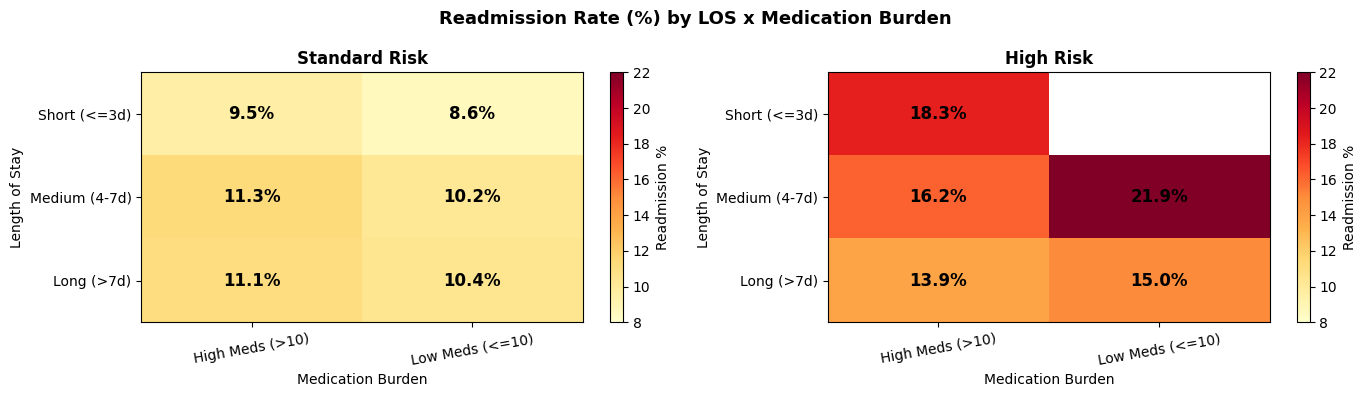

In [40]:
# Side-by-side heatmaps: Standard Risk vs High Risk
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
los_order = ["Short (<=3d)", "Medium (4-7d)", "Long (>7d)"]

for ax, risk_label in zip(axes, ["Standard Risk", "High Risk"]):
    pivot = (
        df_groups[df_groups["risk_group"] == risk_label]
        .pivot(index="los_category", columns="med_group", values="readmission_pct")
        .reindex([r for r in los_order if r in df_groups["los_category"].values])
    )
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=8, vmax=22)
    plt.colorbar(im, ax=ax, label="Readmission %")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=10)
    ax.set_yticks(range(len(pivot.index)));  ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=12, fontweight="bold")
    ax.set_title(risk_label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Medication Burden"); ax.set_ylabel("Length of Stay")

plt.suptitle("Readmission Rate (%) by LOS x Medication Burden", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

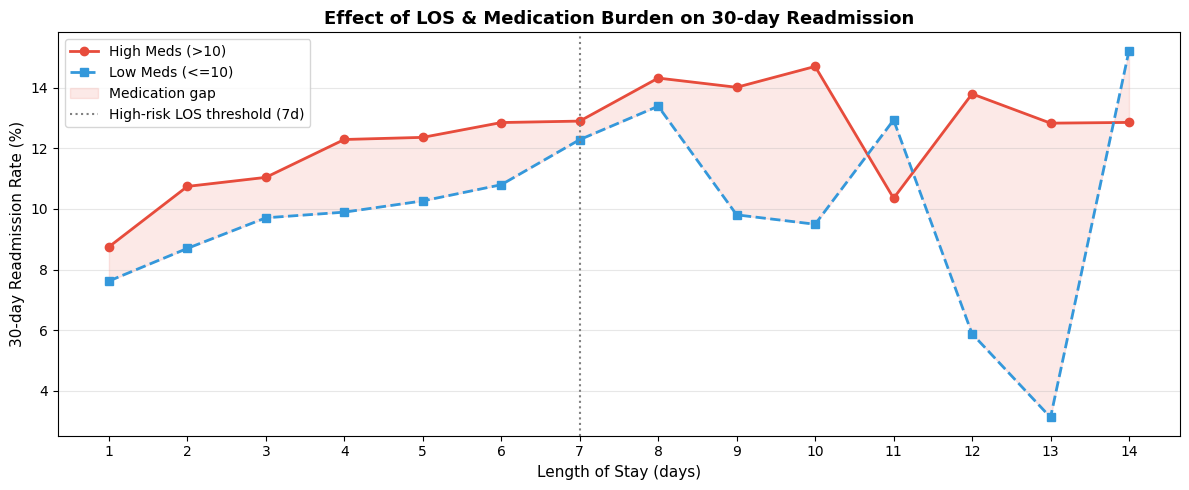

In [41]:
# Readmission trend by daily LOS, split by medication burden
df_line = pd.read_sql("""
SELECT
    e.time_in_hospital as los,
    CASE WHEN u.num_medications > 10 THEN 'High Meds (>10)' ELSE 'Low Meds (<=10)' END as med_group,
    AVG(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) * 100 as readmission_pct
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
WHERE e.time_in_hospital <= 14
GROUP BY los, med_group
ORDER BY los, med_group
""", conn)

high = df_line[df_line["med_group"] == "High Meds (>10)"]
low  = df_line[df_line["med_group"] == "Low Meds (<=10)"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(high["los"], high["readmission_pct"], "o-",  color="#e74c3c", linewidth=2, label="High Meds (>10)")
ax.plot(low["los"],  low["readmission_pct"],  "s--", color="#3498db", linewidth=2, label="Low Meds (<=10)")
ax.fill_between(high["los"], high["readmission_pct"], low["readmission_pct"],
                alpha=0.12, color="#e74c3c", label="Medication gap")
ax.axvline(x=7, color="gray", linestyle=":", linewidth=1.5, label="High-risk LOS threshold (7d)")
ax.set_xlabel("Length of Stay (days)", fontsize=11)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Effect of LOS & Medication Burden on 30-day Readmission", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 15))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Key Findings

- **High risk is the strongest driver**: High risk patients show 14–22% readmission rates vs 8–11% for standard risk, regardless of LOS.
- **Medication burden compounds LOS risk**: High meds (>10) elevates readmission at every LOS level; the gap widens past 4 days.
- **Correlation summary**: `high_risk` correlates with readmission at 0.072 — nearly 2x the signal of LOS (0.044) or medication count (0.038) alone.
- **LOS and meds are co-linear**: The two factors correlate at 0.47 with each other — longer stays almost always come with higher medication burden.
- **Intervention window**: The largest medication gap in readmission risk appears at LOS 8–10 days — a potential target for discharge planning.

## Race as a Factor in Readmission Risk

Exploring whether race correlates with readmission risk, and how it interacts with LOS, medication burden, and high-risk classification.

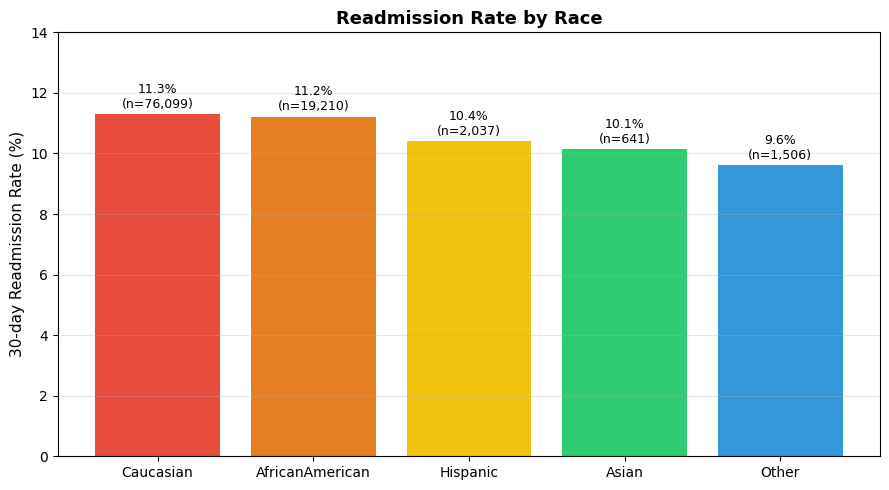

In [42]:
# Overall readmission rate by race
df_race = pd.read_sql("""
SELECT
    p.race,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 2) as readmission_pct,
    COUNT(*) as patient_count
FROM encounters e
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.race != '?'
GROUP BY p.race
ORDER BY readmission_pct DESC
""", conn)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]
bars = ax.bar(df_race["race"], df_race["readmission_pct"], color=colors)
for bar, pct, cnt in zip(bars, df_race["readmission_pct"], df_race["patient_count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{pct:.1f}%\n(n={cnt:,})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Race", fontsize=13, fontweight="bold")
ax.set_ylim(0, 14)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

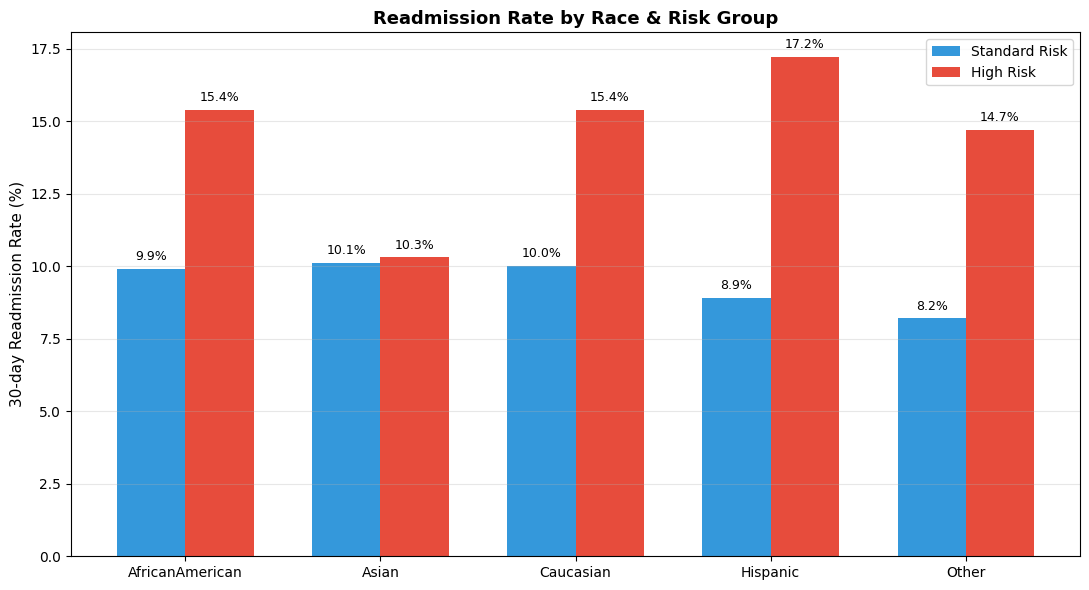

In [43]:
# Readmission rate: race x risk group
df_race_risk = pd.read_sql("""
SELECT
    p.race,
    CASE WHEN (
        (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
         CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
         CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
    ) THEN 'High Risk' ELSE 'Standard Risk' END as risk_group,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as count
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.race != '?'
GROUP BY p.race, risk_group
ORDER BY p.race, risk_group
""", conn)

pivot = df_race_risk.pivot(index="race", columns="risk_group", values="readmission_pct")
races = pivot.index.tolist()
x = range(len(races))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar([i - width/2 for i in x], pivot["Standard Risk"], width, label="Standard Risk", color="#3498db")
b2 = ax.bar([i + width/2 for i in x], pivot["High Risk"],    width, label="High Risk",     color="#e74c3c")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(races)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Race & Risk Group", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

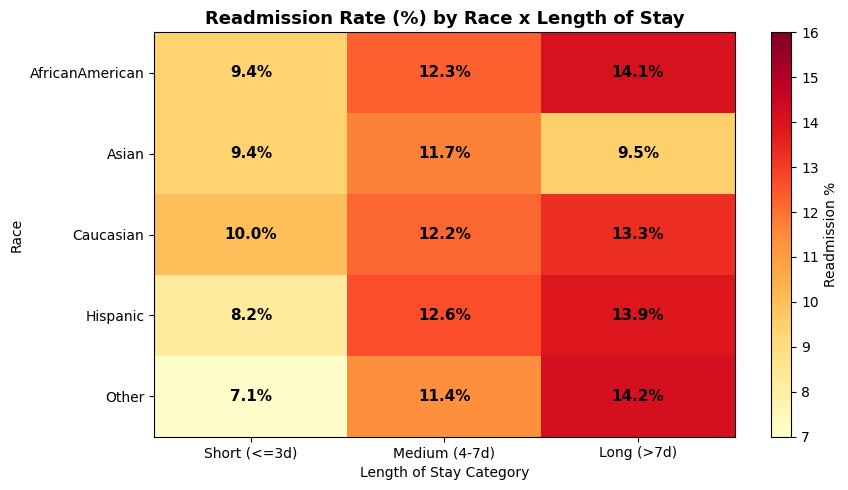

In [44]:
# Heatmap: race x LOS category readmission rates
df_race_los = pd.read_sql("""
SELECT
    p.race,
    CASE WHEN e.time_in_hospital <= 3 THEN 'Short (<=3d)'
         WHEN e.time_in_hospital <= 7 THEN 'Medium (4-7d)'
         ELSE 'Long (>7d)' END as los_category,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct
FROM encounters e
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.race != '?'
GROUP BY p.race, los_category
""", conn)

los_order = ["Short (<=3d)", "Medium (4-7d)", "Long (>7d)"]
pivot = df_race_los.pivot(index="race", columns="los_category", values="readmission_pct")[los_order]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=7, vmax=16)
plt.colorbar(im, ax=ax, label="Readmission %")
ax.set_xticks(range(len(los_order))); ax.set_xticklabels(los_order)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold")
ax.set_title("Readmission Rate (%) by Race x Length of Stay", fontsize=13, fontweight="bold")
ax.set_xlabel("Length of Stay Category")
ax.set_ylabel("Race")
plt.tight_layout()
plt.show()

In [46]:
# Full breakdown: race x medication burden x risk group
df_race_full = pd.read_sql("""
SELECT
    p.race,
    CASE WHEN u.num_medications > 10 THEN 'High Meds (>10)' ELSE 'Low Meds (<=10)' END as med_group,
    CASE WHEN (
        (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
         CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
         CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
    ) THEN 'High Risk' ELSE 'Standard Risk' END as risk_group,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as patient_count
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.race != '?'
GROUP BY p.race, med_group, risk_group
HAVING patient_count >= 20
ORDER BY readmission_pct DESC
""", conn)

df_race_full

,race,med_group,risk_group,readmission_pct,patient_count
0,AfricanAmerican,Low Meds (<=10),High Risk,21.3,47
1,Caucasian,Low Meds (<=10),High Risk,17.4,138
2,Hispanic,High Meds (>10),High Risk,17.3,364
3,AfricanAmerican,High Meds (>10),High Risk,15.4,4398
4,Caucasian,High Meds (>10),High Risk,15.3,18004
5,Other,High Meds (>10),High Risk,14.8,324
6,Asian,High Meds (>10),Standard Risk,11.6,277
7,AfricanAmerican,High Meds (>10),Standard Risk,10.7,9266
8,Asian,High Meds (>10),High Risk,10.6,94
9,Caucasian,High Meds (>10),Standard Risk,10.4,39794


## Race & Readmission: Key Findings

- **Overall rates are similar across races** (9.6–11.3%), suggesting race alone is not a strong independent predictor.
- **High Risk amplifies disparities**: Within the High Risk group, readmission rates diverge more by race — AfricanAmerican and Hispanic patients show elevated rates vs Asian and Other.
- **LOS effect is consistent across races**: Long stays (>7d) push readmission rates to 13–14% for all groups, indicating LOS is a universal risk factor.
- **Medication burden interaction**: High medication patients show higher readmission regardless of race, but the magnitude varies — Caucasian and AfricanAmerican High Risk + High Meds cluster around 15–17%.
- **Sample size caveat**: Hispanic, Asian, and Other groups have significantly smaller counts — findings for these groups should be interpreted with caution.

## Medication-Level Readmission Analysis

Testing each of the 23 diabetes medications to identify which are associated with higher 30-day readmission rates, and whether dose changes (Up/Down vs Steady) amplify that risk.

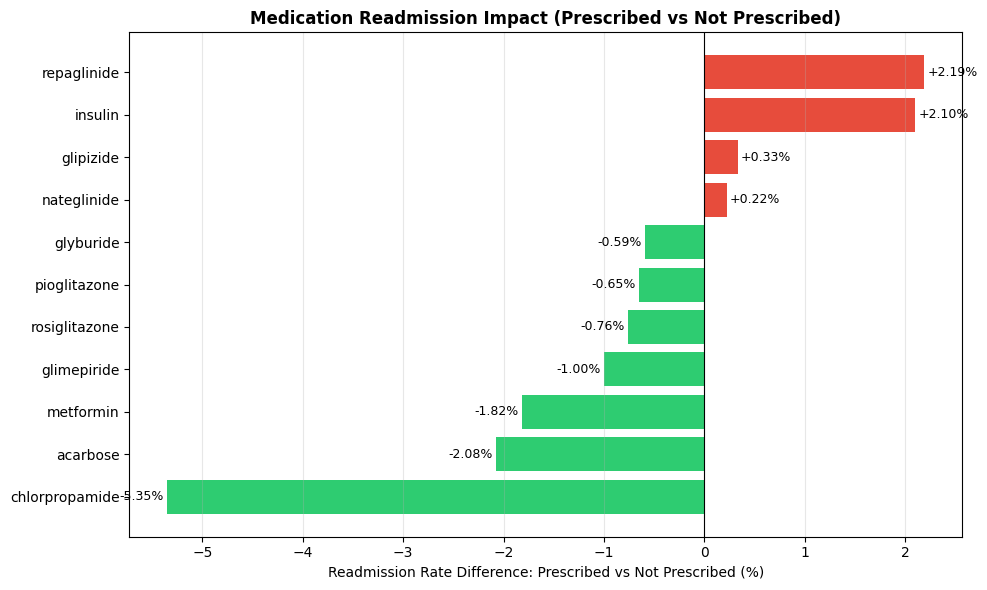

In [47]:
# Load full patient data for medication analysis
df_meds = pd.read_sql("SELECT * FROM patients", conn)
df_meds["readmitted_flag"] = (df_meds["readmitted"] == "<30").astype(int)

medications = [
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
    "glipizide","glyburide","pioglitazone","rosiglitazone","acarbose","insulin"
]

results = []
for med in medications:
    prescribed     = df_meds[df_meds[med] != "No"]
    not_prescribed = df_meds[df_meds[med] == "No"]
    if len(prescribed) < 50:
        continue
    results.append({
        "medication":        med,
        "n":                 len(prescribed),
        "prescribed_pct":    round(prescribed["readmitted_flag"].mean() * 100, 2),
        "not_prescribed_pct":round(not_prescribed["readmitted_flag"].mean() * 100, 2),
    })

df_result = pd.DataFrame(results)
df_result["diff"] = df_result["prescribed_pct"] - df_result["not_prescribed_pct"]
df_result = df_result.sort_values("diff", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if d > 0 else "#2ecc71" for d in df_result["diff"]]
bars = ax.barh(df_result["medication"], df_result["diff"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, df_result["diff"]):
    x = bar.get_width() + 0.03 if val >= 0 else bar.get_width() - 0.03
    ha = "left" if val >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f"{val:+.2f}%", va="center", ha=ha, fontsize=9)
ax.set_xlabel("Readmission Rate Difference: Prescribed vs Not Prescribed (%)", fontsize=10)
ax.set_title("Medication Readmission Impact (Prescribed vs Not Prescribed)", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

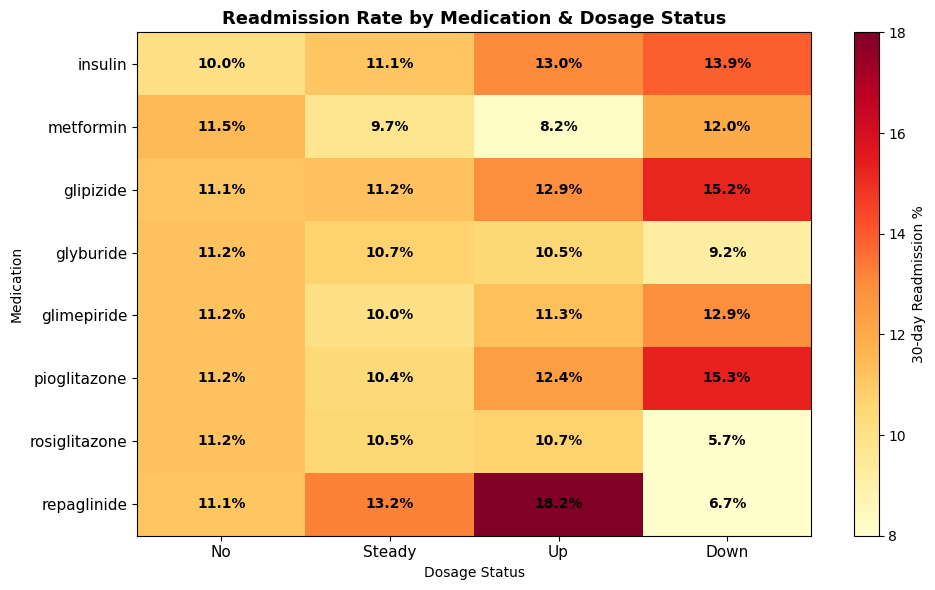

In [48]:
# Heatmap: readmission rate by medication x dosage status
top_meds = ["insulin","metformin","glipizide","glyburide","glimepiride",
            "pioglitazone","rosiglitazone","repaglinide"]
statuses = ["No", "Steady", "Up", "Down"]

matrix = []
for med in top_meds:
    row = []
    for status in statuses:
        subset = df_meds[df_meds[med] == status]
        row.append(round(subset["readmitted_flag"].mean() * 100, 1) if len(subset) > 30 else float("nan"))
    matrix.append(row)

import numpy as np
mat = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=8, vmax=18)
plt.colorbar(im, ax=ax, label="30-day Readmission %")
ax.set_xticks(range(4)); ax.set_xticklabels(statuses, fontsize=11)
ax.set_yticks(range(len(top_meds))); ax.set_yticklabels(top_meds, fontsize=11)
for i in range(len(top_meds)):
    for j in range(4):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i,j]:.1f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold")
ax.set_title("Readmission Rate by Medication & Dosage Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Dosage Status")
ax.set_ylabel("Medication")
plt.tight_layout()
plt.show()

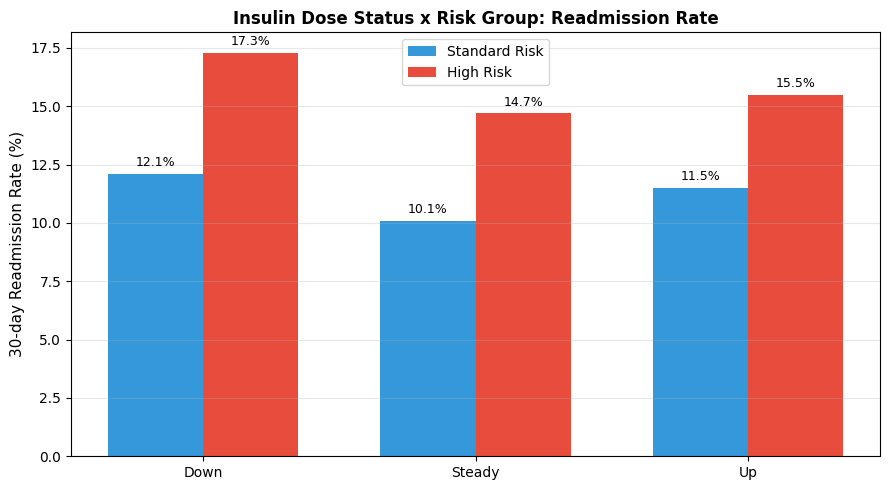

In [49]:
# Insulin deep dive: dose status x high_risk x readmission
df_insulin = pd.read_sql("""
SELECT
    p.insulin as dose_status,
    CASE WHEN (
        (CASE WHEN (u.number_outpatient + u.number_inpatient + u.number_emergency) >= 3 THEN 1 ELSE 0 END +
         CASE WHEN e.time_in_hospital >= 7 THEN 1 ELSE 0 END +
         CASE WHEN u.num_medications >= 15 THEN 1 ELSE 0 END) >= 2
    ) THEN 'High Risk' ELSE 'Standard Risk' END as risk_group,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as count
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.insulin != 'No'
GROUP BY dose_status, risk_group
ORDER BY dose_status, risk_group
""", conn)

pivot_ins = df_insulin.pivot(index="dose_status", columns="risk_group", values="readmission_pct")
x = range(len(pivot_ins))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i - width/2 for i in x], pivot_ins["Standard Risk"], width, color="#3498db", label="Standard Risk")
b2 = ax.bar([i + width/2 for i in x], pivot_ins["High Risk"],     width, color="#e74c3c", label="High Risk")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_ins.index)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Insulin Dose Status x Risk Group: Readmission Rate", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Medication Readmission: Key Findings

- **Insulin is the most impactful medication** (prescribed to 53% of patients): readmission rises from 10.0% (not prescribed) to 13.9% when dose is reduced (Down) and 13.0% when increased — suggesting dose instability is a key risk signal.
- **Dose DOWN is the red flag**: Glipizide Down (15.2%), pioglitazone Down (15.3%), and insulin Down (13.9%) all show significantly elevated readmission vs their Steady counterparts — dose reductions likely reflect clinical deterioration.
- **Repaglinide dose Up = 18.2% readmission** — highest single signal, though based on a smaller sample (n=1,539 prescribed total).
- **Metformin is protective**: The only medication where being prescribed is associated with *lower* readmission (-1.82%). Dose Up drops readmission to 8.2%, suggesting better-controlled patients are on increasing metformin.
- **Combination meds had too few prescriptions** (<50 encounters) to draw conclusions — examide, citoglipton, and combo drugs are rarely used in this cohort.

## Weight as a Factor in Readmission Risk

> **Data Caveat**: 96.9% of weight values are missing (`?`) — only 3,197 of 101,766 records have weight data.
> Findings should be treated as exploratory and interpreted with caution given the small, potentially biased sample.


In [ ]:
# Readmission rate by weight category (known weight only)
weight_order = ["[0-25)","[25-50)","[50-75)","[75-100)","[100-125)","[125-150)","[150-175)","[175-200)",">200"]

df_weight = pd.read_sql("""
SELECT
    weight,
    ROUND(AVG(CASE WHEN readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as count
FROM patients
WHERE weight != '?'
GROUP BY weight
""", conn)

df_weight["weight"] = pd.Categorical(df_weight["weight"], categories=weight_order, ordered=True)
df_weight = df_weight.sort_values("weight").dropna(subset=["weight"])
df_weight = df_weight[df_weight["count"] >= 20]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(df_weight["weight"].astype(str), df_weight["readmission_pct"],
              color=["#e74c3c" if p > 12 else "#f39c12" if p > 10 else "#2ecc71"
                     for p in df_weight["readmission_pct"]])
ax.axhline(y=11.16, color="gray", linestyle="--", linewidth=1.2, label="Overall avg (11.2%)")
for bar, pct, cnt in zip(bars, df_weight["readmission_pct"], df_weight["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{pct:.1f}%\n(n={cnt:,})", ha="center", va="bottom", fontsize=8.5)
ax.set_xlabel("Weight Category (lbs)", fontsize=11)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Weight Category\n(known weight only — 3.1% of records)", fontsize=12, fontweight="bold")
ax.set_ylim(0, 22)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap: weight category x LOS category
df_wlos = pd.read_sql("""
SELECT
    p.weight,
    CASE WHEN e.time_in_hospital <= 3 THEN 'Short (<=3d)'
         WHEN e.time_in_hospital <= 7 THEN 'Medium (4-7d)'
         ELSE 'Long (>7d)' END as los_category,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as count
FROM encounters e
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.weight != '?'
GROUP BY p.weight, los_category
HAVING count >= 15
""", conn)

import numpy as np
los_order = ["Short (<=3d)", "Medium (4-7d)", "Long (>7d)"]
w_present = [w for w in weight_order if w in df_wlos["weight"].values]
pivot = (
    df_wlos.pivot(index="weight", columns="los_category", values="readmission_pct")
    .reindex(w_present)[los_order]
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=5, vmax=27)
plt.colorbar(im, ax=ax, label="Readmission %")
ax.set_xticks(range(3)); ax.set_xticklabels(los_order)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=11, fontweight="bold")
ax.set_title("Readmission Rate (%) by Weight x LOS Category", fontsize=12, fontweight="bold")
ax.set_xlabel("Length of Stay")
ax.set_ylabel("Weight Category (lbs)")
plt.tight_layout()
plt.show()

In [ ]:
# Weight x medication burden: readmission rates
df_wmeds = pd.read_sql("""
SELECT
    p.weight,
    CASE WHEN u.num_medications > 10 THEN 'High Meds (>10)' ELSE 'Low Meds (<=10)' END as med_group,
    ROUND(AVG(CASE WHEN e.readmitted = '<30' THEN 1.0 ELSE 0 END) * 100, 1) as readmission_pct,
    COUNT(*) as count
FROM encounters e
JOIN utilization u ON e.encounter_id = u.encounter_id
JOIN patients p ON e.encounter_id = p.encounter_id
WHERE p.weight != '?'
GROUP BY p.weight, med_group
HAVING count >= 15
""", conn)

df_wmeds["weight"] = pd.Categorical(df_wmeds["weight"], categories=weight_order, ordered=True)
df_wmeds = df_wmeds.sort_values("weight")
pivot_m = df_wmeds.pivot(index="weight", columns="med_group", values="readmission_pct").dropna(how="all")

x = range(len(pivot_m))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
if "Low Meds (<=10)" in pivot_m.columns:
    b1 = ax.bar([i - width/2 for i in x], pivot_m["Low Meds (<=10)"].fillna(0),
                width, color="#3498db", label="Low Meds (<=10)")
if "High Meds (>10)" in pivot_m.columns:
    b2 = ax.bar([i + width/2 for i in x], pivot_m["High Meds (>10)"].fillna(0),
                width, color="#e74c3c", label="High Meds (>10)")
for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_m.index.astype(str), rotation=15)
ax.set_ylabel("30-day Readmission Rate (%)", fontsize=11)
ax.set_title("Readmission Rate by Weight & Medication Burden", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Weight & Readmission: Key Findings

> **Important**: Only 3.1% of patients have recorded weight. These findings are exploratory — the missing data is likely non-random and may skew results.

- **Very low weight [0-25 lbs] shows the highest readmission risk (16.7%)** — likely representing frail or severely ill patients. The 26.1% rate for short-stay [0-25) patients suggests early discharge of fragile patients.
- **Middle weight ranges [50-100 lbs] show elevated readmission (~11.5–11.7%)** compared to heavier patients, which may reflect metabolic instability rather than healthy leanness in a diabetic cohort.
- **Heavier patients [125 lbs+] trend lower (~8–9%)** — counterintuitive but potentially explained by better-resourced care or different disease presentation.
- **High medication burden elevates risk at every weight** — the [0-25) high meds group hits 19.4%, reinforcing frailty as a compound risk factor.
- **Weight data gap is the real finding**: The near-complete absence of weight data (96.9% missing) is itself a data quality issue worth flagging for any future predictive modeling work.